In [1]:
__version__ = '20260527' # yyyymmdd

# Testing the DESI AGN / Galaxy Classification (`agngal`) Value-Added Catalog: DR2 test suite
**Authors:** Claire Greenwell (Durham University), Ben Floyd (University of Portsmouth), Stéphanie Juneau (NSF NOIRLab), Becky Canning (University of Portsmouth), Galaxy & Quasar Physics (GQP) working group  

## Aims

The DESI DR2 value-added catalog (VAC; Juneau, Canning, Mezcua et al., in prep.) includes **galaxies and quasars** from all targets (MWS, BGS, LRG, ELG, QSO as well as secondary targets; [Myers et al. 2023](https://ui.adsabs.harvard.edu/abs/2023AJ....165...50M/abstract)). The DR2 version is significantly larger than DR1. Before constructing the full DR2 version, we need to run tests on a subset to verify that the pipeline is operating correctly. 

This notebook provides a base and example for constructing tests to verify the AGN/Gal VAC. It starts with importing the catalogs, both the full versions and a subset of rows and/or columns, then shows a quick example of one type of test.

## Testing categories

There are three major categories of tests we need to do:
1. Bitmask/Flag propagation and consistency
    - Check that all target bitmasks have properly migrated from QSO-Maker.
    - Make sure that all diagnostic “Available” Bitmasks and their associated classification bits are applied correctly.
2. Scientific Values
    - For each diagnostic we should define min/max allowable ranges of selection quantities (e.g., flux ratios).
3. Verify Signal-to-Noise ratios are as required


We are also open to other suggestions.

4. Any other QA tests
    - Anything else you think may be useful.


## Important notes
- If you are running the notebook offline, make sure to also download the following accompanying files, as well as the catalog files:
    - agnmask.yaml
    - desiutil_bitmask.py
- For more detailed information and references, please see **the full how-to notebook** "01_how_to_use_agngal_catalog_dr2_testsuite".


### import modules and plot settings
### and define function to decode the bitmasks

In [2]:
# Numpy
import numpy as np
# Plotting stuff and suppressing warnings (dividing by zero)
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')
import sys
import os

# Import Astropy libraries - useful for many astronomy related function
from astropy.table import Table, vstack
from astropy.io import fits
import fitsio

# Settings for matplotlib plots
settings = {
    'font.size':12,
    'axes.linewidth':2.0,
    'xtick.major.size':6.0,
    'xtick.minor.size':4.0,
    'xtick.major.width':2.0,
    'xtick.minor.width':1.,
    'xtick.direction':'in', 
    'xtick.minor.visible':True,
    'xtick.top':True,
    'ytick.major.size':6.0,
    'ytick.minor.size':4.0,
    'ytick.major.width':2.0,
    'ytick.minor.width':1.,
    'ytick.direction':'in', 
    'ytick.minor.visible':True,
    'ytick.right':True,
    'axes.labelsize':14
}

plt.rcParams.update(**settings)

In [3]:
def get_agn_maskbits(file):
    import yaml
    from desiutil_bitmask import BitMask
    file_yaml = open(file, 'r')
    yaml_defs = yaml.safe_load(file_yaml)
    
    AGN_MASKBITS = BitMask('AGN_MASKBITS', yaml_defs)
    OPT_UV_TYPE = BitMask('OPT_UV_TYPE', yaml_defs)
    IR_TYPE = BitMask('IR_TYPE', yaml_defs)
    
    return AGN_MASKBITS, OPT_UV_TYPE, IR_TYPE

### location of catalog files and information

In [4]:
# Set the directory of the catalog file here:
# This is currently a Loa test catalog suite made up of the EDR-like survey/programs
# It is in a number of separate files
catdir = '/global/cfs/cdirs/desicollab/science/gqp/agncatalog/dr2/'  # NERSC
#catdir = './' # Local copy

# Catalog filenames
file_vac_list = os.listdir(catdir)

In [5]:
# Open the first catalog to get information about the extensions
agn_hdul = fits.open(f'{catdir}/{file_vac_list[0]}', format='fits')
agn_hdul.info()

Filename: /global/cfs/cdirs/desicollab/science/gqp/agncatalog/dr2//desi_agngal_loa_special-bright.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  AGNCAT        1 BinTableHDU     99   325494R x 41C   [K, 7A, 6A, J, D, K, D, D, D, D, E, E, 6A, K, K, K, J, D, D, K, D, D, D, I, E, L, L, L, K, K, K, K, K, K, K, K, K, K, K, K, K]   
  2  AUXDATA       1 BinTableHDU    182   325494R x 58C   [K, 7A, 6A, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E]   


As we can see there are two extensions:
- Ext[1] is called AGNCAT and includes the catalog of galaxies and quasars with classifications
- Ext[2] is called AUXDATA and includes the auxilary data used for creating the diagnostics diagrams (emission line measurements and stellar mass estimates from FastSpecFit; WISE fluxes from Tractor)

Below we will read both extensions at `T` for the main table, and `T2` for extension 2.

### import full catalog - masked out for now, but use for full tests

### import subset of columns

In [6]:
%%time

## We will create a smaller sample by selecting only the Main survey 
## with a unique spectrum per object (MAIN_PRIMARY=True) with no Redshift warnings (ZWARN=0)
## (takes 30 seconds for DR2 test suite)
select_cols = ['TARGETID','SURVEY','ZWARN','MAIN_PRIMARY']

# Read in a table with just a few columns for sample selection purposes
T_selection = Table()
keep_rows_list = []

for file_vac in file_vac_list:
    with fitsio.FITS(f'{catdir}/{file_vac}') as fitsagn:
        agn_tabledata = fitsagn[1].read(columns=select_cols)
        t_temp = Table(agn_tabledata)
        T_selection = vstack([T_selection, t_temp])
        
        ## Create mask for the selection
        keep = (t_temp['SURVEY']=='main')&(t_temp['MAIN_PRIMARY']==True)&(t_temp['ZWARN']==0)
        
        ## Obtain rows indices that satisfy the criteria
        keep_rows = np.where(keep)[0]
        keep_rows_list.append(keep_rows)

        print(f'{file_vac}\nrows: {len(t_temp)}, kept: {len(keep_rows)}\n')

desi_agngal_loa_special-bright.fits
rows: 325494, kept: 303728

desi_agngal_loa_sv1-dark.fits
rows: 2285745, kept: 2135771

desi_agngal_loa_sv1-other.fits
rows: 408754, kept: 379991

desi_agngal_loa_special-dark.fits
rows: 2693426, kept: 2559247

desi_agngal_loa_sv2-bright.fits
rows: 749725, kept: 697965

desi_agngal_loa_special-backup.fits
rows: 60372, kept: 54289

desi_agngal_loa_sv2-dark.fits
rows: 307648, kept: 286998

desi_agngal_loa_sv3-dark.fits
rows: 141886, kept: 137063

desi_agngal_loa_sv3-bright.fits
rows: 60466, kept: 56406

desi_agngal_loa_sv2-backup.fits
rows: 2359953, kept: 2209092

desi_agngal_loa_cmx-other.fits
rows: 2765, kept: 0

desi_agngal_loa_sv3-backup.fits
rows: 69672, kept: 65009

desi_agngal_loa_sv1-backup.fits
rows: 3141532, kept: 3008269

desi_agngal_loa_sv1-bright.fits
rows: 641198, kept: 614286

CPU times: user 23.3 s, sys: 10.3 s, total: 33.6 s
Wall time: 43.8 s


In [7]:
# this is contains every row in the table, but only some columns
# which has already considerably sped up import
print(len(T_selection))

13248636


### import subset of rows and columns

In [8]:
%%time

## Cutting unique spectra from the Main survey with ZWARN=0 
## still gives a large number of objects. 
## We'll keep 50k per file, using the flags defined previously
## this will run quickly (~5-10 seconds)

## Choice of columns of interest
ext1_cols = ['TARGETID','SURVEY','PROGRAM','Z','ZWARN','SPECTYPE',\
            'AGN_MASKBITS','OPT_UV_TYPE','IR_TYPE']

T = Table()
T2 = Table()

for keep_rows, file_vac in zip(keep_rows_list, file_vac_list):

    rows_1e6 = keep_rows[:50000]
    
    with fitsio.FITS(f'{catdir}/{file_vac}') as fitsagn:
        # first extension
        agn_tabledata_1 = fitsagn[1].read(columns=ext1_cols, rows=rows_1e6)
        T = vstack([T, Table(agn_tabledata_1)])

        # second extension (all columns from this one)
        agn_tabledata_2 = fitsagn[2].read(rows=rows_1e6)
        T2 = vstack([T2, Table(agn_tabledata_2)])

CPU times: user 6.24 s, sys: 694 ms, total: 6.93 s
Wall time: 7.1 s


In [9]:
# this is now a much smaller version of the two tables that can be used to more quickly run initial tests
print(len(T))
print(len(T2))

650000
650000


### get catalog information

In [10]:
AGN_MASKBITS, OPT_UV_TYPE, IR_TYPE = get_agn_maskbits('./agnmask.yaml')

These are the bitmask which contain the infomation. The format of these bitmasks is:    

    - [name of the target bit,  bit value,  "description as a string"]
    
For example:

    - [NII_SY,           8, "NII BPT Seyfert"]
    
This means the name of the target bit is NII_SY, its bit value is 2$^{8}$ and its description is a Seyfert object according to the NII BPT.

In [11]:
# example of applying this:
is_nii_liner = (T['OPT_UV_TYPE'] & OPT_UV_TYPE.NII_LINER != 0)
len(T[is_nii_liner])

3467

### example test

In this section I will set up a test of some BPT diagram results.

The desired result is:
- SNR of all lines involved is within expected limits (this was set during catalog creation to be minimum 3)

Start with some functions for repeated checks.

In [12]:
def check_snr(line_snr, subset_flag, label, min_snr=3.):
    # checks that the SNR for a single line is above a defined minimum
    # by selection should all be >=3
    # only counts lines that should be included on the plot (i.e. that are flagged as e.g. starforming
    num_excesses = np.count_nonzero(line_snr[subset_flag]<min_snr)
    if num_excesses>0:
        print(f'{label} warning! {num_excesses}/{len(line_snr[subset_flag])} SNR values < {min_snr}')
    return num_excesses

In [13]:
def check_bpt_snrs(snr_list, snr_label_list, flag_list, flag_label_list):
    # iterates through each line then each flag for the current plot
    N_badsnr = 0
    for snr, snr_label in zip(snr_list, snr_label_list):
        for flag, flag_label in zip(flag_list, flag_label_list):
            N_badsnr += check_snr(snr, flag, f'{flag_label} - {snr_label}')#, min_snr=5.)
    
    if N_badsnr==0:
        print('no SNR issues')

Now move on to the first BPT diagram: [OIII]/Hbeta vs [NII]/Halpha.

We can create the ratios and extract the flags from the catalog. Then we calculate the SNRs and test them. This is only done for anything that is flagged as being in one of the categories. One reason for not being assigned one of these flags should be lack of good SNR in one line.

In [14]:
# [NII] BPT diagram x and y plot values
xx_bptnii = np.log10(T2['NII_6584_FLUX']/T2['HALPHA_FLUX'])
yy_bpt = np.log10(T2['OIII_5007_FLUX']/T2['HBETA_FLUX'])

# [NII] BPT diagram classification flags
is_nii_sf = (T['OPT_UV_TYPE'] & OPT_UV_TYPE.NII_SF != 0)
is_nii_sy = (T['OPT_UV_TYPE'] & OPT_UV_TYPE.NII_SY != 0)
is_nii_lin = (T['OPT_UV_TYPE'] & OPT_UV_TYPE.NII_LINER != 0)
is_nii_comp = (T['OPT_UV_TYPE'] & OPT_UV_TYPE.NII_COMP != 0)

# [NII] BPT diagram SNRs
nii_snr = T2['NII_6584_FLUX']/(1/np.sqrt(T2['NII_6584_FLUX_IVAR']))
halpha_snr = T2['HALPHA_FLUX']/(1/np.sqrt(T2['HALPHA_FLUX_IVAR']))
oiii_snr = T2['OIII_5007_FLUX']/(1/np.sqrt(T2['OIII_5007_FLUX_IVAR']))
hbeta_snr = T2['HBETA_FLUX']/(1/np.sqrt(T2['HBETA_FLUX_IVAR']))

# check SNRs for all [NII] BPT contributing lines
check_bpt_snrs([oiii_snr, hbeta_snr, nii_snr, halpha_snr],\
               ['OIII', 'Hbeta', 'NII', 'Halpha'],\
               [is_nii_sf, is_nii_sy, is_nii_lin, is_nii_comp],\
               ['NII-BPT SF', 'NII-BPT Seyfert', 'NII-BPT LINER', 'NII-BPT composite'])

no SNR issues


So we have found no problems with SNR in the [NII] section.

Now another BPT diagram: [OIII]/Hbeta vs [OI]/Halpha.

In [15]:
# [OI] BPT diagram x and y plot values
xx_bptoi = np.log10(T2['OI_6300_FLUX']/T2['HALPHA_FLUX'])
yy_bpt = np.log10(T2['OIII_5007_FLUX']/T2['HBETA_FLUX'])

# [OI] BPT diagram classification flags
is_oi_sf = (T['OPT_UV_TYPE'] & OPT_UV_TYPE.OI_SF != 0)
is_oi_sy = (T['OPT_UV_TYPE'] & OPT_UV_TYPE.OI_SY != 0)
is_oi_lin = (T['OPT_UV_TYPE'] & OPT_UV_TYPE.OI_LINER != 0)

# [OI] BPT diagram SNRs
oi_snr = T2['OI_6300_FLUX']/(1/np.sqrt(T2['OI_6300_FLUX_IVAR']))
halpha_snr = T2['HALPHA_FLUX']/(1/np.sqrt(T2['HALPHA_FLUX_IVAR']))
oiii_snr = T2['OIII_5007_FLUX']/(1/np.sqrt(T2['OIII_5007_FLUX_IVAR']))
hbeta_snr = T2['HBETA_FLUX']/(1/np.sqrt(T2['HBETA_FLUX_IVAR']))

# check SNRs for all [OI] BPT contributing lines
check_bpt_snrs([oiii_snr, hbeta_snr, oi_snr, halpha_snr], ['OIII', 'Hbeta', 'OI', 'Halpha'],\
               [is_oi_sf, is_oi_sy, is_oi_lin], ['OI-BPT SF', 'OI-BPT Seyfert', 'OI-BPT LINER'])

OI-BPT SF - OI warning! 83150/157807 SNR values < 3.0
OI-BPT Seyfert - OI warning! 1694/6918 SNR values < 3.0
OI-BPT LINER - OI warning! 908/2846 SNR values < 3.0


But there does appear to be a problem with SNR in the [OI] section. Some [OI] fluxes that have been used have SNRs below our minimum value.

At this point more investigation could be done to try and find a pattern in the problem targets, it can be reported to the DR2 leads, or raised as an issue on github.

For example, we can look at a plot of SNR:

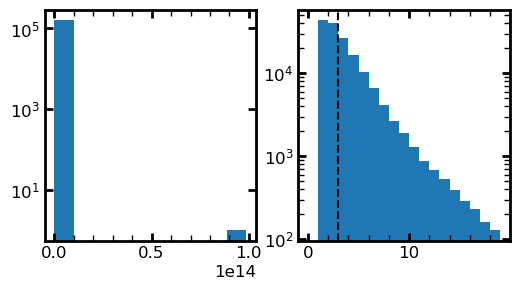

In [16]:
plt.figure(figsize = (6, 3))

plt.subplot2grid((1,2), (0,0))

plt.hist(oi_snr[is_oi_sf])
plt.yscale('log')

plt.subplot2grid((1,2), (0,1))

plt.hist(oi_snr[is_oi_sf], bins=np.arange(0., 20., 1.))
plt.axvline(3., linestyle='--', color='k')
plt.yscale('log')

plt.show()

And from this we can tell that a different SNR limit has been applied than expected.

We can also see that there is a source with an unreasonably high SNR.

In [17]:
# The source in the SF region we found above:
T2_oi_sf = T2[is_oi_sf]
high_oi_sf_snr = T2_oi_sf['OI_6300_FLUX']/(1/np.sqrt(T2_oi_sf['OI_6300_FLUX_IVAR']))>1e12

T2_oi_sf[high_oi_sf_snr]['TARGETID','OI_6300_FLUX','OI_6300_FLUX_IVAR']

TARGETID,OI_6300_FLUX,OI_6300_FLUX_IVAR
int64,float32,float32
2305843025475074967,0.0009816965,1.01218106e+34


In [18]:
# In fact there are several more in the whole catalog that have obviously poor IVAR values:
T2[oi_snr>1e12]['TARGETID','OI_6300_FLUX','OI_6300_FLUX_IVAR']

TARGETID,OI_6300_FLUX,OI_6300_FLUX_IVAR
int64,float32,float32
2305843025475074967,0.0009816965,1.01218106e+34
2305843033918183339,39.981575,8.673775e+22
2305843040335521393,0.00058971555,5.0287623e+36
2305843041056907572,0.0005301763,9.528726e+34
2305843041056928881,0.00090667664,1.2996469e+37
2305843041057110933,0.00027088771,1.5017694e+33
2305843042894077984,0.005916512,8.405205e+33


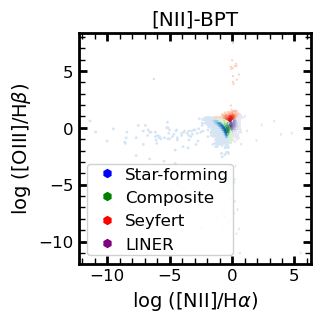

In [19]:
## [NII] BPT diagram plot

## Parameters for all plots
norm_min, norm_max = 0.3, 300

## Initialize figure
plt.figure(figsize = (3, 3))

plt.subplot2grid((1,1), (0,0))
plt.title('[NII]-BPT')
plt.hexbin(xx_bptnii[is_nii_sf], yy_bpt[is_nii_sf], bins=100, norm=LogNorm(norm_min, norm_max), cmap='Blues')
plt.hexbin(xx_bptnii[is_nii_sy], yy_bpt[is_nii_sy], bins=100, norm=LogNorm(norm_min, norm_max), cmap='Reds')
plt.hexbin(xx_bptnii[is_nii_comp], yy_bpt[is_nii_comp], bins=100, norm=LogNorm(norm_min, norm_max), cmap='Greens')
plt.hexbin(xx_bptnii[is_nii_lin], yy_bpt[is_nii_lin], bins=100, norm=LogNorm(norm_min, norm_max), cmap='Purples')
plt.xlabel('log ([NII]/H$\\alpha$)')
plt.ylabel('log ([OIII]/H$\\beta$)')
# plt.xlim(-2.7,1.2)
# plt.ylim(-1.7,2)

legend_elements = [
    Line2D([0], [0], marker='h', color='w', markerfacecolor='b', markersize=8, label="Star-forming"),
    Line2D([0], [0], marker='h', color='w', markerfacecolor='g', markersize=8, label="Composite"),
    Line2D([0], [0], marker='h', color='w', markerfacecolor='r', markersize=8, label="Seyfert"), 
    Line2D([0], [0], marker='h', color='w', markerfacecolor='purple', markersize=8, label="LINER")
]
plt.legend(handles=legend_elements, loc='lower left', fontsize=12, framealpha=0.9, 
           handletextpad=0.1, borderpad=0.2)

plt.show()

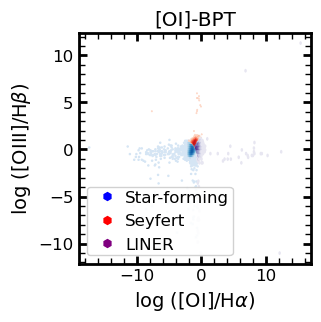

In [20]:
## [OI] BPT diagram plot

## Parameters for all plots
norm_min, norm_max = 0.3, 300

## Initialize figure
plt.figure(figsize = (3, 3))

plt.subplot2grid((1,1), (0,0))
plt.title('[OI]-BPT')
plt.hexbin(xx_bptoi[is_oi_sf], yy_bpt[is_oi_sf], bins=100, norm=LogNorm(norm_min, norm_max), cmap='Blues')
plt.hexbin(xx_bptoi[is_oi_sy], yy_bpt[is_oi_sy], bins=100, norm=LogNorm(norm_min, norm_max), cmap='Reds')
plt.hexbin(xx_bptoi[is_oi_lin], yy_bpt[is_oi_lin], bins=100, norm=LogNorm(norm_min, norm_max), cmap='Purples')
plt.xlabel('log ([OI]/H$\\alpha$)')
plt.ylabel('log ([OIII]/H$\\beta$)')
# plt.xlim(-2.7,1.2)
# plt.ylim(-1.7,2)

legend_elements = [
    Line2D([0], [0], marker='h', color='w', markerfacecolor='b', markersize=8, label="Star-forming"),
    Line2D([0], [0], marker='h', color='w', markerfacecolor='r', markersize=8, label="Seyfert"), 
    Line2D([0], [0], marker='h', color='w', markerfacecolor='purple', markersize=8, label="LINER")
]
plt.legend(handles=legend_elements, loc='lower left', fontsize=12, framealpha=0.9, 
           handletextpad=0.1, borderpad=0.2)

plt.show()